In [2]:
import pickle
import pandas as pd
from pathlib import Path

# --- 1. Define the paths to both .pkl files ---
file_path_fuzzy = Path("../outputs/fuzzy vs non fuzzy/M_1.000_Tirr_150.0_Tint_186.6_Met_0.00_Core_10.0_fsed_1.0_kzz_8.0_sigma_0.05.pkl")
file_path_nonfuzzy = Path("../outputs/fuzzy vs non fuzzy/M_1.000_Tirr_150.0_Tint_127.7_Met_0.00_Core_10.0_fsed_1.0_kzz_8.0_sigma_0.00.pkl")

# --- 2. Create a helper function to load and extract ---
def load_model_data(file_path, label_name):
    if not file_path.exists():
        print(f"❌ File not found: {file_path}")
        return None
        
    with open(file_path, "rb") as f:
        model_data = pickle.load(f)
        
    params = model_data.get("parameters", model_data.get("final_params", {}))
    status = model_data.get("status", "UNKNOWN")
    iterations = model_data.get("iterations", model_data.get("iteration", "N/A"))
    profile_df = model_data.get("profile", model_data.get("stitched_profile"))
    
    print("="*50)
    print(f"🌍 MODEL SUMMARY: {label_name}")
    print("="*50)
    print(f"Status        : {status.upper()} (in {iterations} iterations)")
    print(f"Target Mass   : {params.get('mass', 0):.3f} M_Jup")
    print(f"True Calc Mass: {params.get('true_mass_Mjup', 0):.3f} M_Jup")
    print(f"Core Mass     : {params.get('core_mass_earth', 0)} M_Earth")
    print(f"1-bar Gravity : {params.get('g_1bar', 0):.2f} m/s²")
    print(f"T_int (True)  : {params.get('T_int', 0):.1f} K")
    print("="*50 + "\n")
    
    return model_data

# --- 3. Load both datasets into memory ---
model_fuzzy = load_model_data(file_path_fuzzy, "FUZZY (Sigma = 0.05)")
model_nonfuzzy = load_model_data(file_path_nonfuzzy, "NON-FUZZY (Sigma = 0.0)")

🌍 MODEL SUMMARY: FUZZY (Sigma = 0.05)
Status        : CONVERGED (in 6 iterations)
Target Mass   : 1.000 M_Jup
True Calc Mass: 0.998 M_Jup
Core Mass     : 10.0 M_Earth
1-bar Gravity : 96.96 m/s²
T_int (True)  : 186.6 K

🌍 MODEL SUMMARY: NON-FUZZY (Sigma = 0.0)
Status        : CONVERGED (in 4 iterations)
Target Mass   : 1.000 M_Jup
True Calc Mass: 1.000 M_Jup
Core Mass     : 10.0 M_Earth
1-bar Gravity : 24.57 m/s²
T_int (True)  : 127.7 K



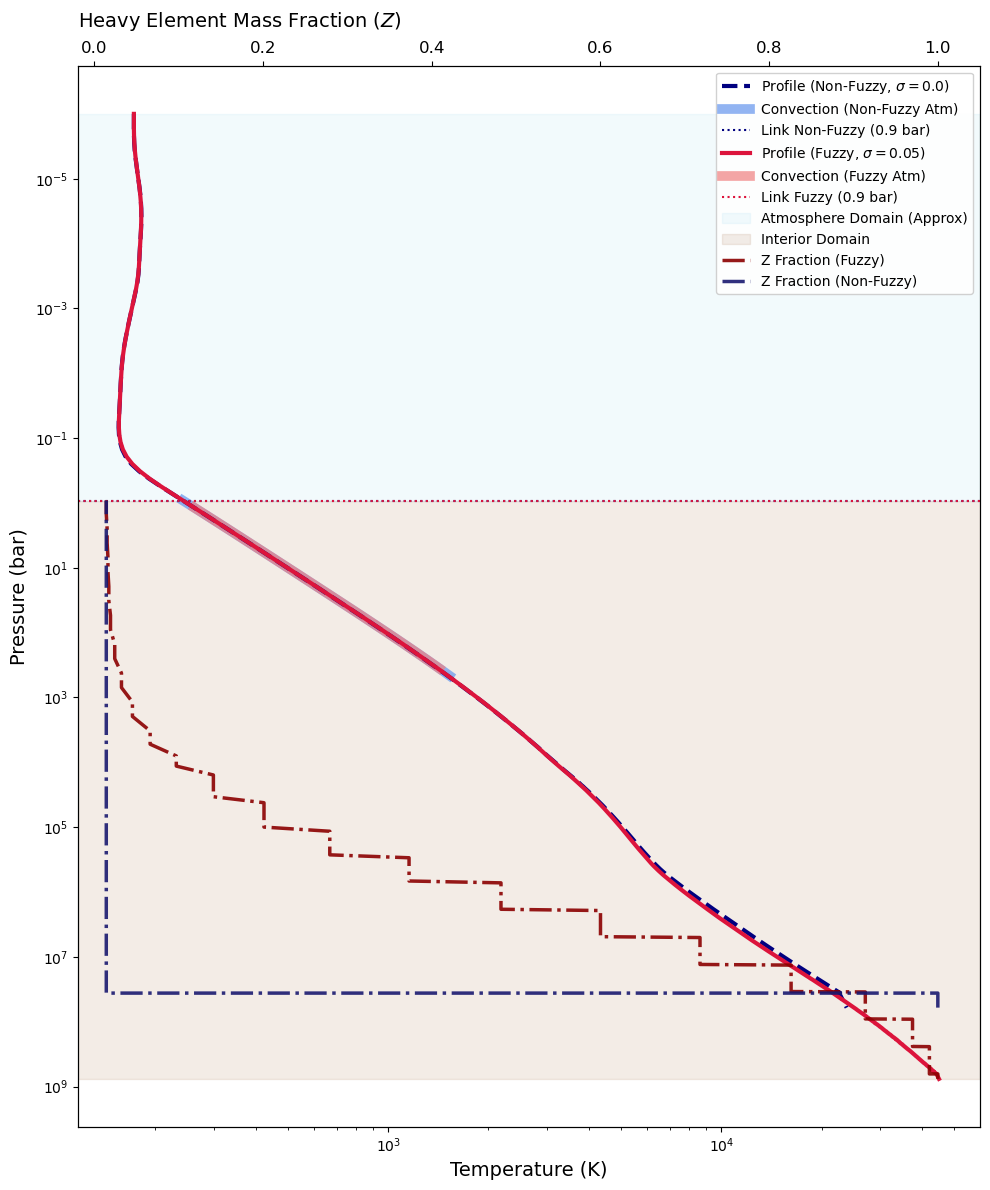

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure both models loaded successfully before plotting
if model_fuzzy and model_nonfuzzy:
    fig, ax = plt.subplots(figsize=(10, 12))

    # ==========================================
    # A. EXTRACT & PLOT NON-FUZZY MODEL (BLUES)
    # ==========================================
    df_nf = model_nonfuzzy.get("profile", model_nonfuzzy.get("stitched_profile"))
    p_link_nf = model_nonfuzzy.get("parameters", model_nonfuzzy.get("final_params", {})).get('p_link_bar', 1000)
    atm_raw_nf = model_nonfuzzy['atmosphere_raw']
    
    # 1. Stitched Profile
    ax.plot(df_nf['Temperature_K'], df_nf['Pressure_bar'], color='navy', lw=3, linestyle='--', zorder=3, label='Profile (Non-Fuzzy, $\sigma=0.0$)')
    
    # 2. Convective Zones
    p_atm_bar_nf = atm_raw_nf['/outputs/levels/pressure'].iloc[0] / 1e5
    t_atm_nf = atm_raw_nf['/outputs/levels/temperature'].iloc[0]
    is_conv_nf = atm_raw_nf['/outputs/levels/is_convective'].iloc[0].astype(bool)
    t_conv_nf = np.where(is_conv_nf, t_atm_nf, np.nan)
    ax.plot(t_conv_nf, p_atm_bar_nf, color='cornflowerblue', lw=7, alpha=0.7, zorder=2, label='Convection (Non-Fuzzy Atm)')
    
    # 3. Link Boundary
    ax.axhline(p_link_nf, color='navy', linestyle=':', zorder=4, label=f'Link Non-Fuzzy ({p_link_nf:.1f} bar)')


    # ==========================================
    # B. EXTRACT & PLOT FUZZY MODEL (REDS)
    # ==========================================
    df_f = model_fuzzy.get("profile", model_fuzzy.get("stitched_profile"))
    p_link_f = model_fuzzy.get("parameters", model_fuzzy.get("final_params", {})).get('p_link_bar', 1000)
    atm_raw_f = model_fuzzy['atmosphere_raw']
    
    # 1. Stitched Profile
    ax.plot(df_f['Temperature_K'], df_f['Pressure_bar'], color='crimson', lw=3, zorder=3, label='Profile (Fuzzy, $\sigma=0.05$)')
    
    # 2. Convective Zones
    p_atm_bar_f = atm_raw_f['/outputs/levels/pressure'].iloc[0] / 1e5
    t_atm_f = atm_raw_f['/outputs/levels/temperature'].iloc[0]
    is_conv_f = atm_raw_f['/outputs/levels/is_convective'].iloc[0].astype(bool)
    t_conv_f = np.where(is_conv_f, t_atm_f, np.nan)
    ax.plot(t_conv_f, p_atm_bar_f, color='lightcoral', lw=7, alpha=0.7, zorder=2, label='Convection (Fuzzy Atm)')
    
    # 3. Link Boundary
    ax.axhline(p_link_f, color='crimson', linestyle=':', zorder=4, label=f'Link Fuzzy ({p_link_f:.1f} bar)')


    # ==========================================
    # C. ADD HEAVY ELEMENT FRACTION (Z) OVERLAY
    # ==========================================
    # Create a twin X-axis tied to the same Y-axis (Pressure)
    ax_z = ax.twiny()
    
    int_raw_f = model_fuzzy.get('interior_raw', {})
    int_raw_nf = model_nonfuzzy.get('interior_raw', {})
    
    # Plot Fuzzy Z Profile
    if 'P' in int_raw_f and 'Z' in int_raw_f:
        # Convert log10(bars) back to linear bars so it aligns with ax.set_yscale('log')
        # NOTE: If the raw data is actually log10(Pa), use (10**raw_p) / 1e5 instead!
        raw_p_f = np.array(int_raw_f['P'])
        p_int_bar_f = 10**(raw_p_f) 
        
        z_f = np.array(int_raw_f['Z'])
        
        # MASK: Strictly slice arrays to start exactly at or below the linkage point
        mask_f = p_int_bar_f >= p_link_f
        
        ax_z.plot(z_f[mask_f], p_int_bar_f[mask_f], color='darkred', lw=2.5, 
                  linestyle='-.', alpha=0.9, label='Z Fraction (Fuzzy)')
        
    # Plot Non-Fuzzy Z Profile
    if 'P' in int_raw_nf and 'Z' in int_raw_nf:
        raw_p_nf = np.array(int_raw_nf['P'])
        p_int_bar_nf = 10**(raw_p_nf) 
        
        z_nf = np.array(int_raw_nf['Z'])
        
        # MASK: Strictly slice arrays to start exactly at or below the linkage point
        mask_nf = p_int_bar_nf >= p_link_nf
        
        ax_z.plot(z_nf[mask_nf], p_int_bar_nf[mask_nf], color='midnightblue', lw=2.5, 
                  linestyle='-.', alpha=0.9, label='Z Fraction (Non-Fuzzy)')
        
    # Format the Z axis (Top of the plot)
    # Using loc='left' pushes the label to the top-left corner
    ax_z.set_xlabel("Heavy Element Mass Fraction ($Z$)", fontsize=14, color='black', labelpad=10, loc='left')
    ax_z.set_xlim(-0.02, 1.05)  # Z strictly bounds from 0 to 1
    ax_z.tick_params(axis='x', colors='black', labelsize=12)


    # ==========================================
    # D. FORMATTING & DOMAIN SHADING
    # ==========================================
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.invert_yaxis()
    
    ax.set_xlabel("Temperature (K)", fontsize=14)
    ax.set_ylabel("Pressure (bar)", fontsize=14)
    
    # Domain shading
    avg_link = (p_link_nf + p_link_f) / 2
    max_p = max(df_nf['Pressure_bar'].max(), df_f['Pressure_bar'].max())
    
    ax.axhspan(1e-6, avg_link, color='skyblue', alpha=0.1, label='Atmosphere Domain (Approx)')
    ax.axhspan(avg_link, max_p, color='saddlebrown', alpha=0.1, label='Interior Domain')

    # Combine legends from both axes so they appear together nicely
    lines_1, labels_1 = ax.get_legend_handles_labels()
    lines_2, labels_2 = ax_z.get_legend_handles_labels()
    ax.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right', fontsize=10, framealpha=0.9)
    
    plt.tight_layout()
    plt.savefig('../figures/TP_profile_comparison_Jupiter_with_Z.pdf', bbox_inches='tight')
    plt.show()
else:
    print("Cannot generate plot: Missing one or both data files.")

Figure saved to: ../figures/structure_diagnostics.pdf


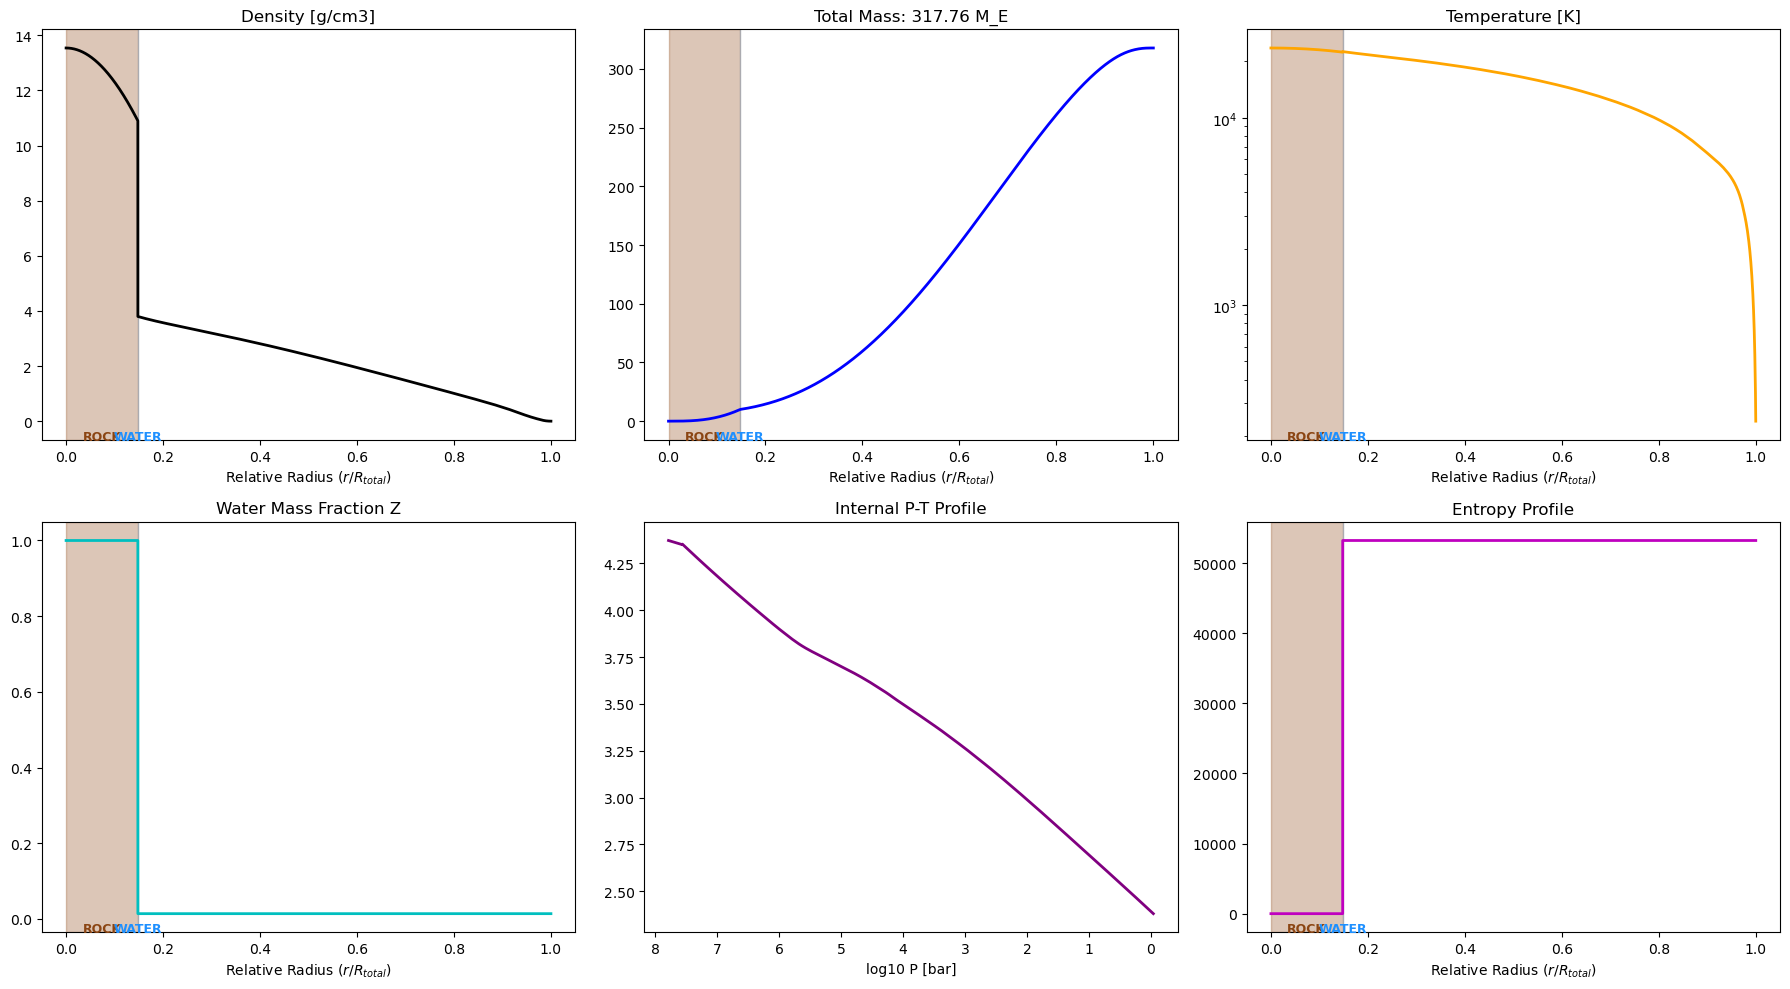

In [5]:
from fuzzycore.plotting import plot_diagnostics

plot_diagnostics(model_nonfuzzy['interior_raw'])

Figure saved to: ../figures/structure_diagnostics.pdf


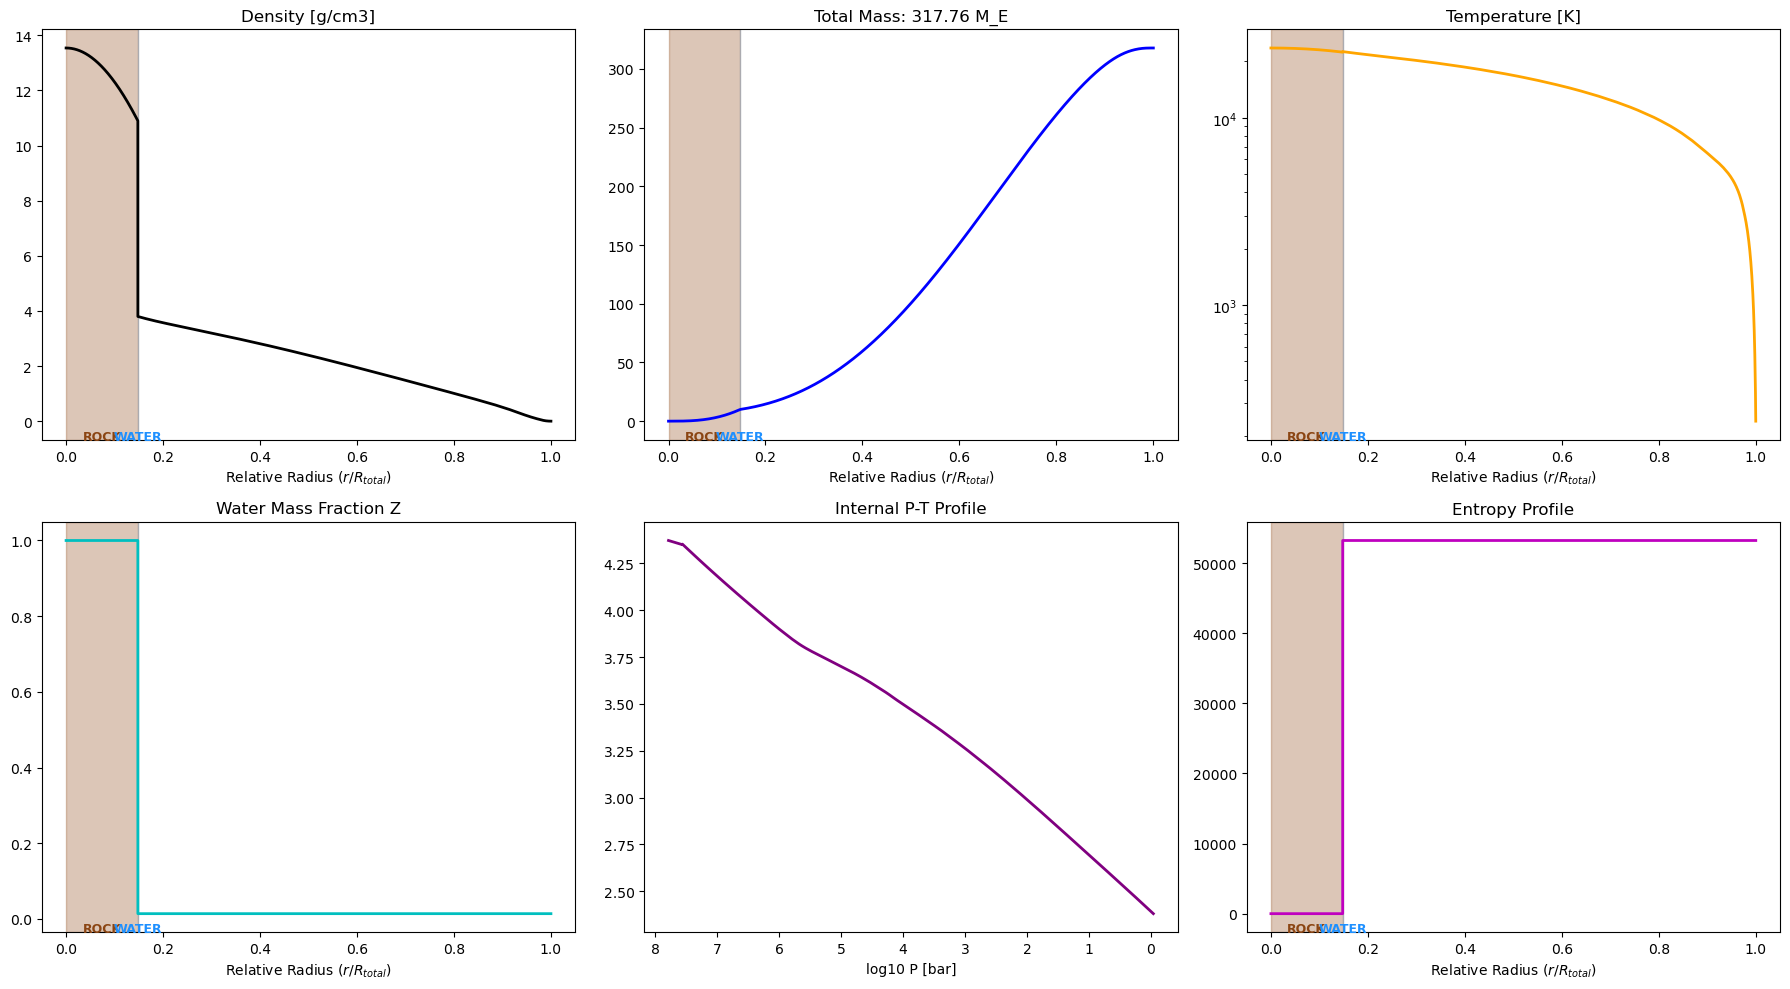

In [ ]:
from fuzzycore.plotting import plot_diagnostics

plot_diagnostics(model_data['interior_raw'])

Figure saved to: ../figures/structure_diagnostics.pdf


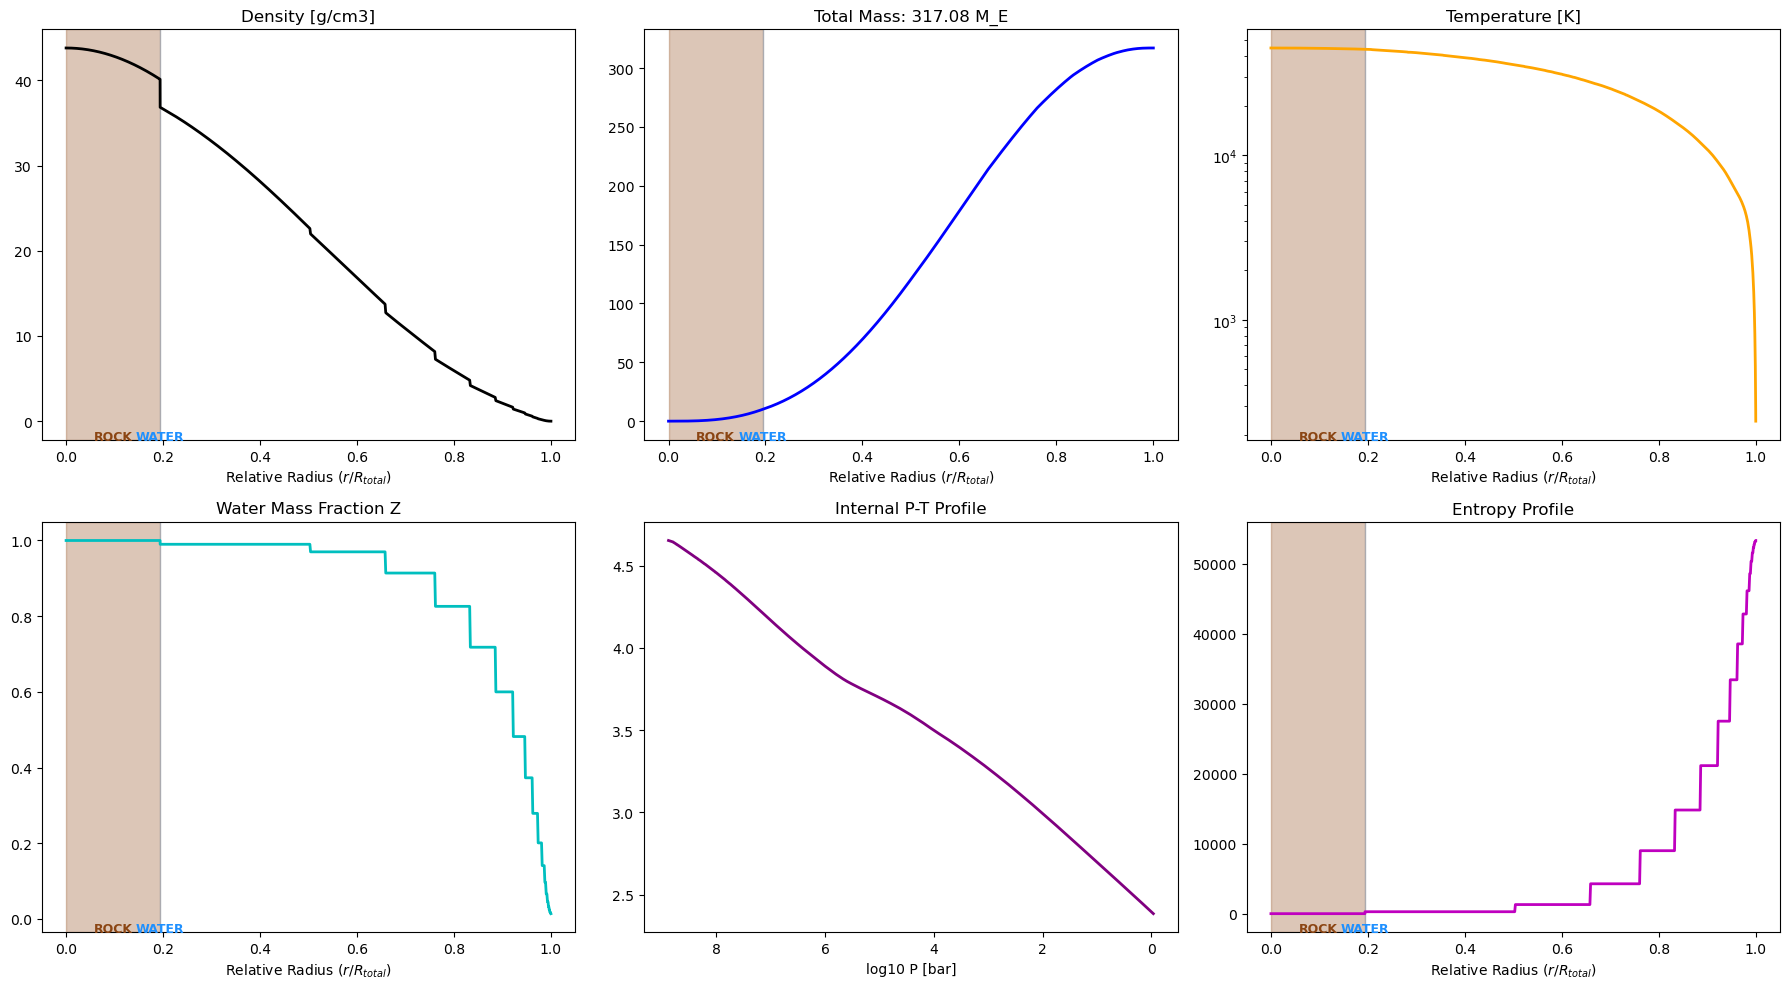

In [6]:
from fuzzycore.plotting import plot_diagnostics

plot_diagnostics(model_fuzzy['interior_raw'])

In [52]:
from fuzzycore import constants as c
model_data['interior_raw']['R_total']/c.R_JUPITER

np.float64(1.0028128092838653)

In [11]:
int_raw_f['P']

array([ 8.88130647,  8.88130558,  8.88130278,  8.88129806,  8.88129144,
        8.88128289,  8.88127244,  8.88126007,  8.88124579,  8.88122959,
        8.88121148,  8.88119145,  8.88116952,  8.88114566,  8.8811199 ,
        8.88109222,  8.88106262,  8.88103111,  8.88099769,  8.88096236,
        8.8809251 ,  8.88088594,  8.88084486,  8.88080186,  8.88075695,
        8.88071013,  8.88066139,  8.88061073,  8.88055816,  8.88050367,
        8.88044727,  8.88038895,  8.88032872,  8.88026657,  8.8802025 ,
        8.88013652,  8.88006862,  8.8799988 ,  8.87992707,  8.87985342,
        8.87977785,  8.87970036,  8.87962096,  8.87953964,  8.8794564 ,
        8.87937124,  8.87928416,  8.87919517,  8.87910425,  8.87901142,
        8.87891667,  8.87881999,  8.8787214 ,  8.87862089,  8.87851845,
        8.8784141 ,  8.87830782,  8.87819962,  8.8780895 ,  8.87797746,
        8.87786349,  8.87774761,  8.8776298 ,  8.87751006,  8.87738841,
        8.87726483,  8.87713932,  8.87701189,  8.87688254,  8.87

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from exowrap import ExoremOut

ExoremOut(model_fuzzy['atmosphere_raw'])

def plot_transmission_spectra_comparison(model_fuzzy: dict, model_nonfuzzy: dict, save_path: str = None, normalize: bool = True):
    """
    Plots a comparison of transmission spectra between a fuzzy and non-fuzzy model.
    If normalize=True, subtracts the median baseline to compare feature amplitudes directly.
    """
    if not model_fuzzy or not model_nonfuzzy:
        print("Missing model data for plotting.")
        return

    try:
        model_fuzzy_out = ExoremOut(model_fuzzy['atmosphere_raw'])
        model_nonfuzzy_out = ExoremOut(model_nonfuzzy['atmosphere_raw'])
        
        # Extract wavelength and transmission depth (assuming ppm)
        wave_f = model_fuzzy_out.wavelength
        depth_f = model_fuzzy_out.transmission
        
        wave_nf = model_nonfuzzy_out.wavelength
        depth_nf = model_nonfuzzy_out.transmission
        
    except KeyError as e:
        print(f"Error extracting transmission spectrum data: Missing key {e}")
        return

    # --- NORMALIZATION LOGIC ---
    if normalize:
        # Subtract the median depth to remove the bulk radius baseline shift
        depth_f = depth_f - np.median(depth_f)
        depth_nf = depth_nf - np.median(depth_nf)
        ylabel = r'$\Delta$ Transit Depth (ppm)'
    else:
        ylabel = 'Transit Depth (ppm)'

    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot Non-Fuzzy first (often lower baseline, good to put in back)
    ax.plot(wave_nf, depth_nf, color='navy', lw=1.5, alpha=0.85, 
            label='Sharp Core ($\sigma=0.0$)')
    
    # Plot Fuzzy on top
    ax.plot(wave_f, depth_f, color='crimson', lw=1.5, alpha=0.85, 
            label='Fuzzy Core ($\sigma=0.05$)')

    ax.set_xscale('log')
    ax.set_xlabel('Wavelength ($\mu$m)', fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    
    # Typical JWST/Ariel wavelength range
    ax.set_xlim(0.6, 30) 
    
    # Optional: Add a subtle zero-line if normalized
    if normalize:
        ax.axhline(0, color='black', linestyle='--', alpha=0.3, zorder=0)
    
    ax.grid(True, which="both", ls=":", alpha=0.6)
    ax.legend(fontsize=12, loc='upper left', framealpha=0.9)
    
    plt.tight_layout()
    
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Transmission spectrum saved to {save_path}")
        
    plt.show()

def plot_emission_spectra_comparison(model_fuzzy: dict, model_nonfuzzy: dict, save_path: str = None):
    """
    Plots a comparison of emission spectra between a fuzzy and non-fuzzy model.
    """
    if not model_fuzzy or not model_nonfuzzy:
        print("Missing model data for plotting.")
        return

    try:
        # Re-initialize the ExoremOut objects
        model_fuzzy_out = ExoremOut(model_fuzzy['atmosphere_raw'])
        model_nonfuzzy_out = ExoremOut(model_nonfuzzy['atmosphere_raw'])
        
        # Extract wavelength and emission flux
        wave_f = model_fuzzy_out.wavelength
        flux_f = model_fuzzy_out.emission_spectral_radiosity
        
        wave_nf = model_nonfuzzy_out.wavelength
        flux_nf = model_nonfuzzy_out.emission_spectral_radiosity
        
    except KeyError as e:
        print(f"Error extracting emission spectrum data: Missing key {e}")
        return

    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot Non-Fuzzy
    ax.plot(wave_nf, flux_nf, color='navy', lw=1.5, alpha=0.85, 
            label='Sharp Core ($\sigma=0.0$)')
    
    # Plot Fuzzy
    ax.plot(wave_f, flux_f, color='crimson', lw=1.5, alpha=0.85, 
            label='Fuzzy Core ($\sigma=0.05$)')

    ax.set_xscale('log')
    ax.set_yscale('log')
    
    ax.set_xlabel('Wavelength ($\mu$m)', fontsize=14)
    
    # --- UNITS ADDED HERE ---
    # Using a raw string (r'') allows Matplotlib to render the LaTeX math formatting correctly
    ax.set_ylabel(r'Emission Flux (W m$^{-2}$ / cm$^{-1}$)', fontsize=14) 
    
    # Typical JWST/Ariel wavelength range (Emission is heavily focused in the IR)
    ax.set_xlim(1.0, 30) 
    
    ax.grid(True, which="both", ls=":", alpha=0.6)
    ax.legend(fontsize=12, loc='upper right', framealpha=0.9)
    
    plt.tight_layout()
    
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        # Note: Fixed the unpacking typo (*save_path) here too just in case!
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Emission spectrum saved to {save_path}")
        
    plt.show()


🔭 Generating Transmission Spectra Comparison...
Transmission spectrum saved to ../figures/Transmission_comparison_Jupiter.pdf


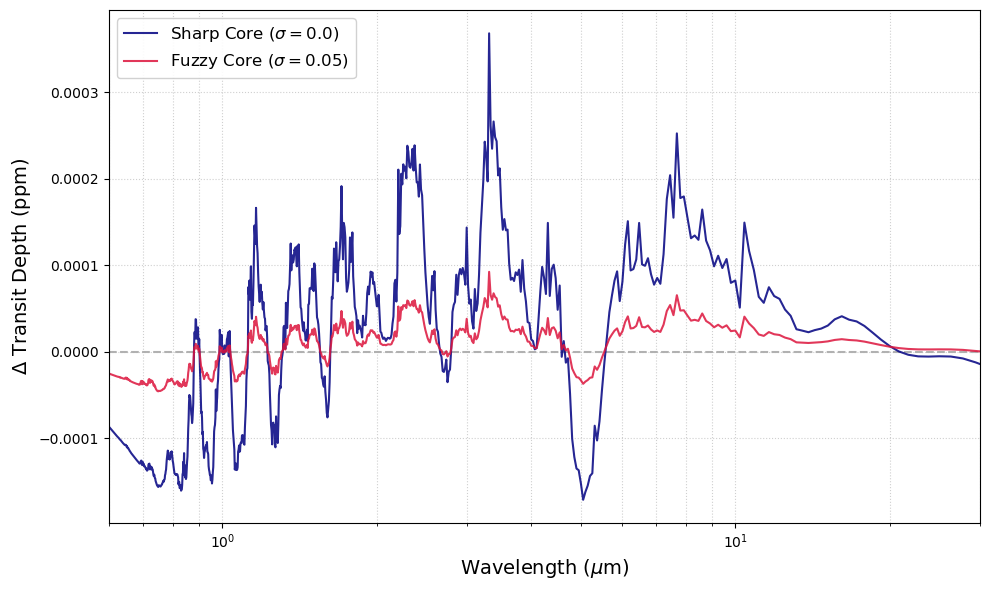

🔥 Generating Emission Spectra Comparison...
Emission spectrum saved to ../figures/Emission_comparison_Jupiter.pdf


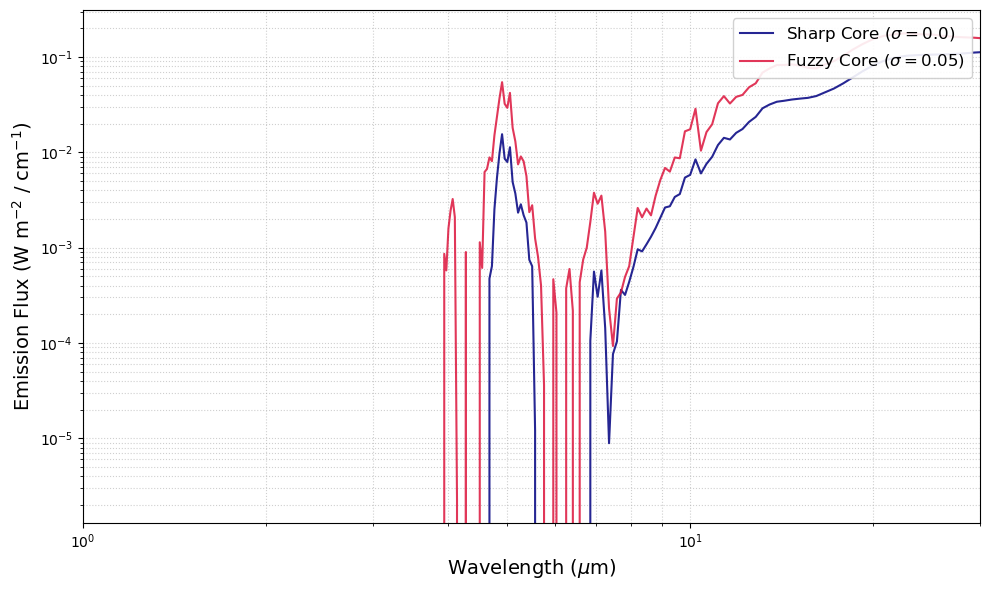

In [5]:
# Ensure models are loaded before attempting to plot
if model_fuzzy and model_nonfuzzy:
    print("🔭 Generating Transmission Spectra Comparison...")
    plot_transmission_spectra_comparison(
        model_fuzzy=model_fuzzy, 
        model_nonfuzzy=model_nonfuzzy, 
        save_path="../figures/Transmission_comparison_Jupiter.pdf"
    )
    
    print("🔥 Generating Emission Spectra Comparison...")
    plot_emission_spectra_comparison(
        model_fuzzy=model_fuzzy, 
        model_nonfuzzy=model_nonfuzzy, 
        save_path="../figures/Emission_comparison_Jupiter.pdf"
    )
else:
    print("❌ Cannot generate spectra plots: Missing one or both data files. Run Cell 1 first.")

In [26]:
ExoremOut(model_fuzzy['atmosphere_raw']).emission_spectral_radiosity
ExoremOut(model_fuzzy['atmosphere_raw']).transmission

array([0.02258006, 0.02257815, 0.02257384, ..., 0.02257355, 0.0225736 ,
       0.02257365], shape=(1502,))